In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cf
import xarray as xr
pd.set_option('display.max_rows', 1000)
import numpy as np

In [10]:
#METADATA
station_metadata_1 = pd.read_csv('/home/queenle/station_FWI_data/raw_metadata/aes_stnhist20210111.csv')
station_metadata_2 = pd.read_csv('/home/queenle/station_FWI_data/raw_metadata/cwfis_allstn2023.csv')
station_metadata = pd.concat([station_metadata_1,station_metadata_2])

#FWI STATION DATA
full_study_area_FWI = pd.read_csv('/home/queenle/station_FWI_data/6month_fire_season_FWI/full_study_area_FWI.csv')
full_study_area_FWI['rep_date'] = pd.to_datetime(full_study_area_FWI['rep_date'])
full_study_area_FWI.set_index('rep_date', inplace=True)
full_study_area_FWI = full_study_area_FWI.where(full_study_area_FWI>1)
# drop selected sites
full_study_area_FWI.drop(['1125073','1096453','1176755','1113543','1160515','1108380','1152106','1161650'],axis=1,inplace=True)

#CANADA STATIONS
drop_sites = []
for station in full_study_area_FWI.columns:  
    if full_study_area_FWI[station].isnull().all():
        full_study_area_FWI.drop(station,axis=1,inplace=True)
        continue
    
    meta_station = station.split('.')[0]
    lat_lon = station_metadata.loc[station_metadata['aes'] == str(meta_station)][['lat','lon']]
    lat = lat_lon.values[0][0]
    lon = lat_lon.values[0][1]+360
    # remove below 49 latitude except BC, Canada
    if lat < 49:
        if station_metadata.loc[station_metadata['aes'] == str(meta_station)]['prov'].values[0] != 'BC':
            drop_sites.append(station)
            
    # remove excessive Alberta stations added post 2002
    if full_study_area_FWI[station].dropna().index.year.values[0] > 2002 and station_metadata.loc[station_metadata['aes'] == str(meta_station)]['prov'].values[0] == 'AB':
        drop_sites.append(station)
        
canada_FWI = full_study_area_FWI.drop(drop_sites,axis=1)

validation_study_sites = canada_FWI.columns

In [66]:
validation_study_sites.values

array(['1018610', '1018620', '1021830', '1026270', '1032730', '1037650',
       '1040390', '1077500', '1084350', '1096450', '1096630', '1100030',
       '1108447', '1113540', '1114740', '1126150', '1126510', '1145730',
       '1154200', '1163780', '3011880', '3012208', '3015520', '3016800',
       '3025480', '3031093', '3031920', '3033880', '3034480', '3036240',
       '3050520', '3053520', '3063680', '3067370', '4016560', '4028040',
       '4045600', '4056240', '4057120', '1025370', '4015320', '3081680',
       '3012210', '1141455', '4043920', '3063685', '1018642', '1036206',
       '1038205', '1091169', '1098940', '1123970', '1152102', '1160899',
       '1176751', '3012205', '3035201', '3062241', '4019035', '1114741',
       '1086556', '3062244', '4036844', '3053520.1', '3062244.1',
       '3067370.1', '3081680.1', '4015320.1', '4016560.1', '4019035.1',
       '4028040.1', '4036844.1', '4045600.1', '4056240.1', '4057120.1',
       '1018610.1', '1018620.1', '1021830.1', '1025370.1', '

In [13]:
df['aes']

0         1018610
1         1018620
2         1021830
3         1026270
4         1031110
           ...   
432854    2100700
432855    2101000
432856    2101100
432857    2101200
432858    2101300
Name: aes, Length: 432859, dtype: int64

In [70]:
directory = '/home/queenle/station_FWI_data/raw_download/'

decade_dfs = []
for i,file in enumerate(['cwfis_fwi1950sv3.0.csv','cwfis_fwi1960sv3.0.csv','cwfis_fwi1970sv3.0.csv','cwfis_fwi1980sv3.0.csv','cwfis_fwi1990sv3.0.csv','cwfis_fwi2000sv3.0opEC_2015.csv','cwfis_fwi2010sopEC.csv','cwfis_fwi2020sopEC.csv']):
    
    print('working on ' + str(1950+10*i) +'s')
    df = pd.read_csv(directory + file)
    df['rep_date'] = pd.to_datetime(df['rep_date'])
    df.set_index('rep_date', inplace=True)
    df['aes'] = df['aes'].astype(str)

    stations = df.loc[df['aes'].isin(validation_study_sites)]
    
    site_dfs = []
    for site in stations['aes'].unique():
        site_ts = stations.loc[stations['aes']==site]['fwi']
        site_ts.name = site
        
        site_dfs.append(site_ts)
        
    decade_dfs.append(pd.concat(site_dfs,axis=1))
    
combined = pd.concat(decade_dfs, axis=0)

working on 1950s
working on 1960s
working on 1970s


/tmp/ipykernel_10428/3648086058.py:7: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(directory + file)


working on 1980s
working on 1990s
working on 2000s
working on 2010s
working on 2020s


In [73]:
combined['1157630'].dropna()

rep_date
1980-04-18 12:00:00    11.6
1980-04-19 12:00:00    19.3
1980-04-20 12:00:00    20.4
1980-04-21 12:00:00     0.4
1980-04-22 12:00:00     1.0
                       ... 
2017-05-13 12:00:00     7.3
2017-05-14 12:00:00     7.9
2017-05-15 12:00:00     9.1
2017-05-16 12:00:00     0.6
2017-05-17 12:00:00     0.0
Name: 1157630, Length: 7027, dtype: float64

In [79]:
fire_season_dfs = []
for site in combined:
    
    ts = combined[site]
    
    select_months = ts.loc[ts.index.month.isin([5,6,7,8,9,10])]
    
    first_year = select_months.dropna().index.year[0]
    first_month = select_months.dropna().index.month[0]
    
    last_year = select_months.dropna().index.year[-1]
    last_month = select_months.dropna().index.month[-1]
    
    fire_season = select_months.resample('Y').mean()
    
    if first_month > 5:
        fire_season.loc[fire_season.index.year==first_year] = np.nan
    
    if last_month < 10:
        fire_season.loc[fire_season.index.year==last_year] = np.nan
    
    fire_season_dfs.append(fire_season)
    
fire_season_df = pd.concat(fire_season_dfs,axis=1)

In [81]:
fire_season_df.to_csv('/home/queenle/station_FWI_data/6month_fire_season_FWI/FWI_draft_3.csv')

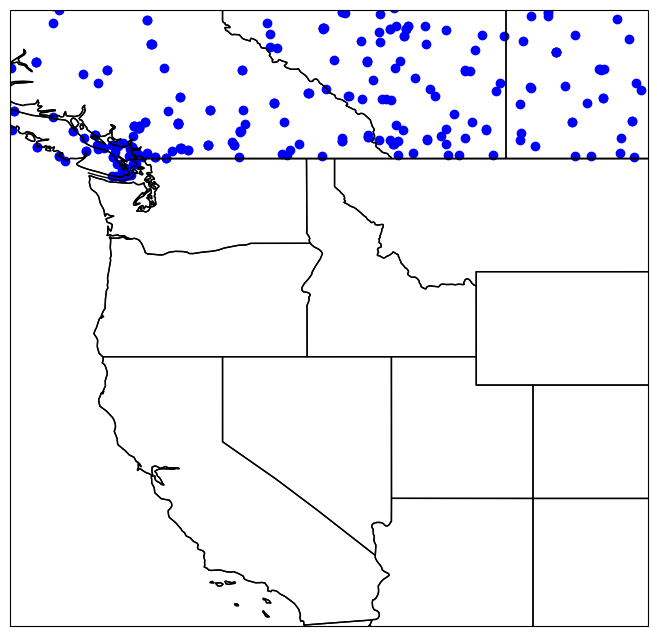

In [67]:
fig,axs = plt.subplots(figsize=(10,8),subplot_kw=dict(projection=ccrs.PlateCarree()))

for site in fire_season_df.columns:

    station = site.split('.')[0]
    lat_lon = station_metadata.loc[station_metadata['aes'] == str(station)][['lat','lon']]
    lat = lat_lon.values[0][0]
    lon = lat_lon.values[0][1]+360

    axs.scatter(lon,lat,c='blue')

axs.coastlines()  # cartopy function
axs.add_feature(cf.BORDERS)
axs.add_feature(cf.STATES)
axs.set_extent([232.5,255, 32.5,54.18])

plt.show()
plt.close()